# Results

# Viewing Results

In [67]:
import json

def load_probability_model(path):
    with open(path, "r", encoding="utf-8") as f:
        model = json.load(f)
    return model

## Perplexity

Metric that measures the uncertainty of a model's predictions. Specifically, in language models, it quantifies how well the model predicts the next word in a sequence. When a model makes a prediction, it assigns probabilities to possible next words.

Let $w_1, w_2, \dots, w_T$ be a sequence of words in the test set.
The perplexity of an $n$-gram language model is defined as:

$$
\text{Perplexity}
= \exp\left(
-\frac{1}{T}
\sum_{t=1}^{T}
\log P\!\left(
w_t \mid w_{t-(n-1)}, \dots, w_{t-1}
\right)
\right)
$$

GeeksforGeeks. (2025, July 23). Perplexity for LLM evaluation. https://www.geeksforgeeks.org/nlp/perplexity-for-llm-evaluation/ 

**Where:**

- $T$ is the total number of tokens (words) in the sentence.

- $w_t$ denotes the word at position $t$ in the sentence.

- $n$ is the order of the N-gram model (e.g., $n = 1$ for a unigram model, $n = 2$ for a bigram model).

- $(w_{t-n+1}, \ldots, w_{t-1})$ represents the $(n-1)$-word context preceding the word $w_t$.

- $P(w_t \mid w_{t-n+1}, \ldots, w_{t-1})$ is the conditional probability assigned by the N-gram model to the word $w_t$ given its preceding context.

- $\sum_{t=1}^{T}$ indicates that the log-probabilities are summed over all word positions in the sentence.

- $\log(\cdot)$ is used to convert the product of probabilities into a sum, which improves numerical stability and interpretability.


In [ ]:
import json
from math import log, exp 
import pandas as pd

# Function to compute the perplexity of an n-gram model on a test dataset where n is the order of the n-gram model, test_csv is the path to the CSV file containing the test n-grams, prob_dicts is a dictionary of probability models for different n values, and epsilon is a small value to avoid log(0)

def compute_perplexity(test_csv, prob_dicts, n, epsilon=1e-12):
    df = pd.read_csv(test_csv)
    log_prob_sum = 0.0
    T = 0

    model = prob_dicts[n]

    for ngram_str in df["N-gram"]:
        ngram = eval(ngram_str)  # ['w1','w2',...]
        target = ngram[-1]

        if n == 1:
            context = "()"
        else:
            context = str(tuple(ngram[:-1]))

        prob = model.get(context, {}).get(target, epsilon)

        log_prob_sum += log(prob)
        T += 1

    return exp(-log_prob_sum / T)

In [70]:
modeltype = "word"	# "word", "character"
category ="all"	# "business", "entertainment", "politics", "sport", "tech", "all"

N = [1, 2, 3, 4, 5]
prob_dicts = {}

for n in N:
    path = f"./../Probability_NGrams/{modeltype}_{n}grams_{category}_probability.json"
    prob_dicts[n] = load_probability_model(path)

perplexities = []

for n in N:
    test_file = f"./../Dataset_NGrams/bbc_word_{n}grams_test.csv"
    ppl = compute_perplexity(test_file, prob_dicts, n)
    perplexities.append(ppl)

perplexities

[1769.073119192971,
 11480.194339482558,
 4144823.409812207,
 153982042.26823324,
 554729288.0715431]

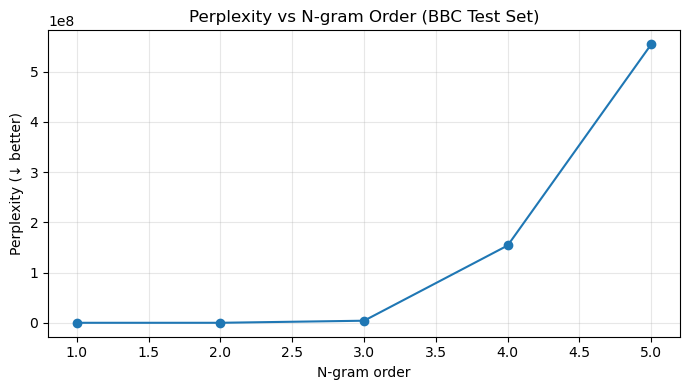

In [44]:
import matplotlib.pyplot as plt

N = [1, 2, 3, 4, 5]

plt.figure(figsize=(7, 4))
plt.plot(N, perplexities, marker="o")
plt.xlabel("N-gram order")
plt.ylabel("Perplexity (↓ better)")
plt.title("Perplexity vs N-gram Order (BBC Test Set)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As the N-gram order increases, perplexity rises sharply. This behavior is expected due to data sparsity: higher-order N-gram models rely on increasingly specific contexts, many of which do not appear in the training data. As a result, the model assigns very low probabilities to test sequences, leading to large perplexity values. Without smoothing or backoff techniques, higher-order models tend to generalize poorly to unseen data despite being more expressive.

## N-gram Accuracy

For each N-gram order, we run the model on testing sentences and measure how often the generated continuation matches the true continuation in the test set. Through this measurement we try to answer: "Does the model’s predicted next word match the actual next word in the dataset?"

$$
\text{Accuracy}_n
=
\frac{
\text{Number of correct next-word predictions}
}{
\text{Total number of predictions}
}
$$

In [64]:
# Function to evaluate next-word prediction accuracy of an n-gram model where prob_model is the probability model, test_sentence is the tokenized reference sentence, and n is the n-gram order

def evaluate_next_word_accuracy(prob_model, test_sentence, n):

    results = []
    correct = 0
    total = 0

    for i in range(len(test_sentence) - n + 1):
        context_words = test_sentence[i:i + n - 1]
        true_next_word = test_sentence[i + n - 1]

        context = str(tuple(context_words)) if n > 1 else "()"

        if context not in prob_model:
            continue  # model cannot predict for this context

        # choose most probable next word
        predicted_word = max(
            prob_model[context],
            key=prob_model[context].get
        )

        is_correct = predicted_word == true_next_word

        results.append(
            (context_words, true_next_word, predicted_word, is_correct)
        )

        correct += int(is_correct)
        total += 1

    accuracy = correct / total if total > 0 else 0.0
    return accuracy, results

In [ ]:
#Function to print detailed evaluation results of the n-gram model where results is the list of evaluation tuples and n is the n-gram order

def print_evaluation(results, n):
    print(f"\nEvaluating {n}-gram model")
    print("=" * 50)

    for context, true_word, predicted_word, is_correct in results:
        context_str = " ".join(context) if context else "<START>"
        status = "✓" if is_correct else "✗"

        print(f"Context: [{context_str}]")
        print(f"True next word:      {true_word}")
        print(f"Predicted next word: {predicted_word}")
        print(f"Correct: {status}")
        print("-" * 50)

In [ ]:
import pandas as pd
from ast import literal_eval

# Function to load a test sentence from a CSV file where csv_path is the path to the CSV file and n is the n-gram order
def load_test_sentence(csv_path, n):
    df = pd.read_csv(csv_path)

    # Take the first n-gram as the seed
    first_ngram = literal_eval(df.iloc[0]["N-gram"])

    sentence = list(first_ngram)

    # Extend sentence using the dataset itself
    for i in range(1, len(df)):
        ngram = literal_eval(df.iloc[i]["N-gram"])
        sentence.append(ngram[-1])

    return sentence

In [81]:
test_sentence = load_test_sentence("./../Dataset_NGrams/bbc_word_5grams_test.csv", 5)

test_sentence[:15]

['<s>',
 'Malaysia',
 'lifts',
 'Islamic',
 'bank',
 'limit',
 'Malaysias',
 'central',
 'bank',
 'is',
 'to',
 'relax',
 'restrictions',
 'on',
 'foreign']

In [ ]:
accuracies = []

for n in range (1, 6):
    accuracy, results = evaluate_next_word_accuracy(
        prob_dicts[n],   
        test_sentence,    
        n
    )

    print_evaluation(results, n)
    print(f"N-gram accuracy: {accuracy:.4f}")

    accuracies.append(accuracy)



Evaluating 1-gram model
Context: [<START>]
True next word:      <s>
Predicted next word: the
Correct: ✗
--------------------------------------------------
Context: [<START>]
True next word:      Malaysia
Predicted next word: the
Correct: ✗
--------------------------------------------------
Context: [<START>]
True next word:      lifts
Predicted next word: the
Correct: ✗
--------------------------------------------------
Context: [<START>]
True next word:      Islamic
Predicted next word: the
Correct: ✗
--------------------------------------------------
Context: [<START>]
True next word:      bank
Predicted next word: the
Correct: ✗
--------------------------------------------------
Context: [<START>]
True next word:      limit
Predicted next word: the
Correct: ✗
--------------------------------------------------
Context: [<START>]
True next word:      Malaysias
Predicted next word: the
Correct: ✗
--------------------------------------------------
Context: [<START>]
True next word:    

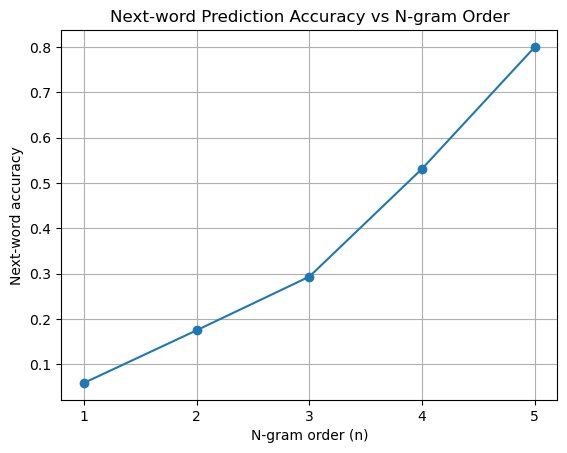

In [84]:
import matplotlib.pyplot as plt

n_values = list(range(1, 6))

plt.figure()
plt.plot(n_values, accuracies, marker='o')
plt.xlabel("N-gram order (n)")
plt.ylabel("Next-word accuracy")
plt.title("Next-word Prediction Accuracy vs N-gram Order")
plt.xticks(n_values)
plt.grid(True)
plt.show()


Perplexity evaluates how well an N-gram model predicts the test data, while N-gram overlap measures how closely generated sequences resemble the empirical N-grams in the dataset. Lower perplexity indicates better generalization, whereas higher overlap reflects closer adherence to observed linguistic patterns.